In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

from generate_colormap import *


from functools import partial
import starsim

In [2]:
pathdata = '/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/'
path_grid="/home/sophie-stucki/starsim/starsim/gif/"
conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_sun.conf"

In [3]:
def simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path, dT_fc=None):
    """
    Iniialization of the starsim simulation for a particular set of parameters

    Params:
            -Q: facular_area_ratio
    Return:
            - ss: starsim object

    """
    
    #create the starsim object
    ss=starsim.StarSim(conf_file_path=conf_file_path)


    #set the Q parameter
    ss.active_region_types=type_list

    if dT_fc !=None:
        ss.facula_T_contrast = dT_fc

    #initialize the spot
    overlap=True

    #TODO: more modulable
    Nspots=len(spot_size_list)
    ss.spot_map=np.zeros([Nspots,8])
    for j in range(Nspots):
        ss.spot_map[j][2]=200#lifetime spot
        ss.spot_map[j][1]=0#appearance time
        ss.spot_map[j][3]=latitude_list[j]#latitude (degrees) [0,180]
        ss.spot_map[j][4]=longitude_list[j]#longitude (degrees)	[0,360]
        ss.spot_map[j][5]=spot_size_list[j]#spot size (degrees)
    return ss

In [4]:
plt.rcParams['font.size'] = 18

def update(frame, ax, fig, lags, scalar_map, t, rv_sim, CCF_p, RV, BIS, raw_xbis, raw_ybis, lc, path_grid):
    ax[1,0].cla()
    ax[1,1].cla()
    lag = lags[frame]

    color_val = scalar_map.to_rgba(rv_sim[lag])
    
    #plot RVs
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,2].plot(t[i],rv_sim[i], color=color_val,marker='.', markersize=12)
    ax[0,2].set_xlim(t.min(),t.max())
    ax[0,2].set_ylim(rv_sim.min()-np.abs(rv_sim.min())/10,rv_sim.max()+np.abs(rv_sim.max())/10)
    ax[0,2].plot(t[:lag],rv_sim[:lag],color='gray', alpha=0.2, linewidth= 1)
    
    #plot CCF
    ax[1,0].plot(RV[:],CCF_p[lag], color=color_val,alpha=0.9)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,0].plot(RV[:],CCF_p[i], color=color_val,alpha=0.1)


    #plot BIS (mean diff)
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,2].plot(t[i],BIS[i], color=color_val,marker='.', linestyle='None', markersize=12)
    ax[1,2].plot(t[:lag],BIS[:lag],color='gray', alpha=0.2, linewidth= 1)

    #plot BIS
    ax[1,1].plot(raw_xbis[lag] - (np.max(raw_xbis[lag]) + np.min(raw_xbis[lag])) / 2,raw_ybis[lag], color=color_val,alpha=1)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,1].plot(raw_xbis[i] - (np.max(raw_xbis[i]) + np.min(raw_xbis[i])) / 2,raw_ybis[i], color=color_val,alpha=0.1)
    ax[1,1].set_xlim(-40, 40)


    #plot flux intensity
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,1].plot(t[i],lc[i], color=color_val,marker='.', markersize=12)
    ax[0,1].set_xlim(t.min(),t.max())
    ax[0,1].plot(t[:lag],lc[:lag],color='gray', alpha=0.2, linewidth= 1)
        
    #generate stellar grid
    x=np.linspace(-0.999,0.999,1000)
    h=np.sqrt((1-x**2)/(np.tan(0)**2+1))

    
    color_dict = { 0:'#CA6702', 1:'#9B2226', 2:'#EE9B00', 3:'#0A9396'}
    #0: photosphere, 1: spot, 2: faculae, 3: planet
    
    vec_grid=np.load(path_grid+'vec_gridt{:.4f}.npy'.format(t[lag]))
    typ=np.load(path_grid+'typt{:.4f}.npy'.format(t[lag]))
    
    #identifies which type of grid element is covering the pixel: photosphere, spot, facualae or planet
    ax[0,0].scatter(vec_grid[:,1],vec_grid[:,2], color=[ color_dict[np.argmax(i)] for i in typ ],s=50, alpha=0.8)
    #ax[0,0].plot(x,h,'k')
    
    ax[1,0].set_ylabel('CCF power')
    ax[1,0].set_xlabel('RV (m/s)')
    ax[1,0].set_ylim(CCF_p.min()-np.abs(CCF_p.min())/10,CCF_p.max()+np.abs(CCF_p.max())/10)
    ax[0,2].set_ylabel('RV (m/s)')
    ax[0,2].set_xlabel('t (d)')
    ax[0,1].set_ylabel('f')
    ax[0,1].set_xlabel('t (d)')
    ax[1,2].set_ylabel('BIS span')
    ax[1,2].set_xlabel('t (D)')
    ax[1,1].set_ylabel('')
    ax[1,1].set_xlabel('BIS')

    ax[0,0].locator_params(axis='y',nbins=5)
    ax[1,0].locator_params(axis='x',nbins=5)

    ax[0,1].ticklabel_format(axis='both', style='sci')
    ax[1,0].ticklabel_format(axis='both', style='sci')

    ax[0,0].tick_params(grid_alpha=0.7)
    ax[0,1].tick_params(grid_alpha=0.7)
    ax[0,2].tick_params(grid_alpha=0.7)
    ax[1,0].tick_params(grid_alpha=0.7)
    ax[1,1].tick_params(grid_alpha=0.7)
    ax[1,2].tick_params(grid_alpha=0.7)

    fig.tight_layout()


def retrieve_observable(ss, t, pathdata, path_grid, output):
    """
    Load and save the #TODO

    Params:
            -ss: starsim object
            -t: timeframe
    
    """

    rv_sim=ss.results['rv']
    CCF=ss.results['CCF'][1:]
    RV=ss.results['CCF'][0]
    lc = ss.results['lc']
    BIS = ss.results['bis']
    raw_xbis = ss.results['raw_xbis']
    raw_ybis = ss.results['raw_ybis']

    np.savetxt(pathdata+'lc_{}.txt'.format(output), lc)
    np.savetxt(pathdata+'rv_{}.txt'.format(output), rv_sim)
    np.savetxt(pathdata+'bis_{}.txt'.format(output), BIS)



    '''
    Generate an animated GIF
    '''

    CCF_p =CCF[:] -np.mean(CCF,axis=0)

    lags = np.arange(len(t))


    # Normalize the continuous variable to map it to the range [0, 1] for the colormap
    norm = Normalize(vmin=-np.max((np.abs(rv_sim))), vmax=np.max((np.abs(rv_sim))))
    List = ['#104f5c', '#2c6570', '#477b83', '#639295', '#84a8a5', '#c7b7a0', '#e49a77', '#e5845f', '#de714d', '#d3603e', '#c65031']

    colormap = get_continuous_cmap(List)
    scalar_map = ScalarMappable(norm=norm, cmap=colormap)

    fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(30/1.5 + 2, 20/1.5))

    # Create an animation
    ani = FuncAnimation(fig, partial(update, ax=ax, fig=fig, lags=lags, scalar_map=scalar_map, t=t, rv_sim=rv_sim, CCF_p=CCF_p, RV=RV, BIS=BIS, raw_xbis=raw_xbis, raw_ybis=raw_ybis, lc=lc, path_grid=path_grid), frames=len(lags), repeat=False)

    # Save the animation as a video
    writer = FFMpegWriter(fps=3                      , metadata=dict(artist='Me'), bitrate=2400)

    
    ani.save(pathdata+output+'.gif', writer=writer)

In [5]:
type_list = [[0], [1], [0, 1], [0, 1], [1, 0]]
spot_size_list = [[5], [0.1 * np.sqrt(10001)], [0.1, 0.1 * np.sqrt(10001)], [2, 2 * np.sqrt(3)], [2 * np.sqrt(3), 2]]
latitude_list = [90, 90]
longitude_list = [250, 250]
ss_list = []
lc_tot = []
rv_tot = []
bis_tot = []
ccf_tot = []


period = 25.05
periods_nbr = 0.8
point_nbr = 2


t=np.linspace(0,period *periods_nbr,int(period *periods_nbr*point_nbr))


In [6]:
for i in range(len(type_list)):
    ss = simulation_init(type_list[i], spot_size_list[i], latitude_list, longitude_list, conf_file_path)
    ss.compute_forward(observables=['lc', 'rv'],t=t)

    ss_list.append(ss)

    lc_tot.append(ss.results['lc'])
    rv_tot.append(ss.results['rv'])
    bis_tot.append(ss.results['bis'])
    # bis_tot[i] -= bis_tot[i][0]
    ccf_tot.append(ss.results['CCF'])



PHOENIX spectra
Date 20.040000000000003. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [40/40]%ELSE
ELSE
RV shift
Date 20.040000000000003. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [40/40]%PHOENIX spectra
Date 20.040000000000003. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [40/40]%ELSE
ELSE
ELSE
RV shift
Date 20.040000000000003. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [40/40]%PHOENIX spectra
Date 20.040000000000003. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [40/40]%ELSE
ELSE
ELSE
RV shift
Date 20.040000000000003. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [40/40]%PHOENIX spectra
Date 20.040000000000003. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [40/40]%ELSE
ELSE
ELSE
RV shift
Date 20.040000000000003. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [40/40]%PHOENIX spectra
Date 20.040000000000003. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [40/40]%ELSE
ELSE


In [7]:
ss.temperature_facula

5808.0

In [8]:
# output = 'T_{}_r_{}_lat_{}_long_{}.gif'.format(type_list, spot_size_list, latitude_list, longitude_list)
# retrieve_observable(ss, t, pathdata, path_grid, output)

In [9]:
lc_sp_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/lc_Q_0_r_[5]_lat_[90]_long_[250].txt')
ff_ph_sp_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/ff_ph_Q_0_r_[5]_lat_[90]_long_[250].txt')
rv_sp_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/rv_Q_0_r_[5]_lat_[90]_long_[250].txt')
bis_sp_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/bis_Q_0_r_[5]_lat_[90]_long_[250].txt')

lc_fc_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/lc_Q_10000.0_r_[0.1]_lat_[90]_long_[250].txt')
ff_ph_fc_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/ff_ph_Q_10000.0_r_[0.1]_lat_[90]_long_[250].txt')
ff_fc_fc_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/ff_fc_Q_10000.0_r_[0.1]_lat_[90]_long_[250].txt')
rv_fc_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/rv_Q_10000.0_r_[0.1]_lat_[90]_long_[250].txt')
bis_fc_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/bis_Q_10000.0_r_[0.1]_lat_[90]_long_[250].txt')

lc_both_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/lc_Q_2_r_[2]_lat_[90]_long_[250].txt')
rv_both_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/rv_Q_2_r_[2]_lat_[90]_long_[250].txt')
bis_both_old = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/bis_Q_2_r_[2]_lat_[90]_long_[250].txt')


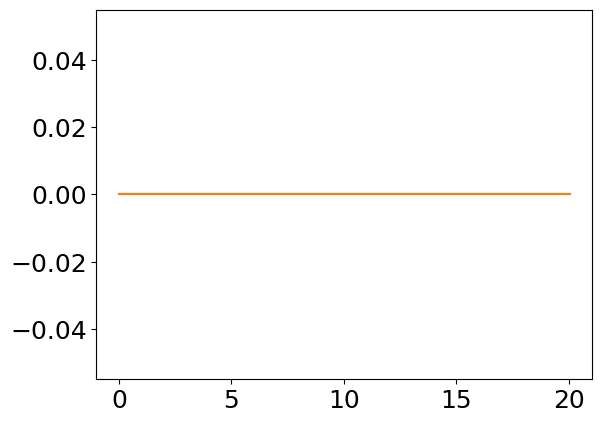

In [10]:
plt.plot(t, ss_list[2].results['ff_fc']-ff_fc_fc_old)
plt.plot(t, ss_list[2].results['ff_ph']-ff_ph_fc_old)


In [11]:
ss_list[2].results['lc']

array([1.        , 1.        , 1.00000051, 1.00011043, 1.00036629,
       1.00064338, 1.00081671, 1.00090089, 1.00092218, 1.00090952,
       1.00088479, 1.00087236, 1.00086906, 1.00087578, 1.00088756,
       1.00089252, 1.0008864 , 1.00087753, 1.00086808, 1.00087264,
       1.00088951, 1.00091404, 1.00092182, 1.00089003, 1.00078751,
       1.00059515, 1.00030512, 1.00007356, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

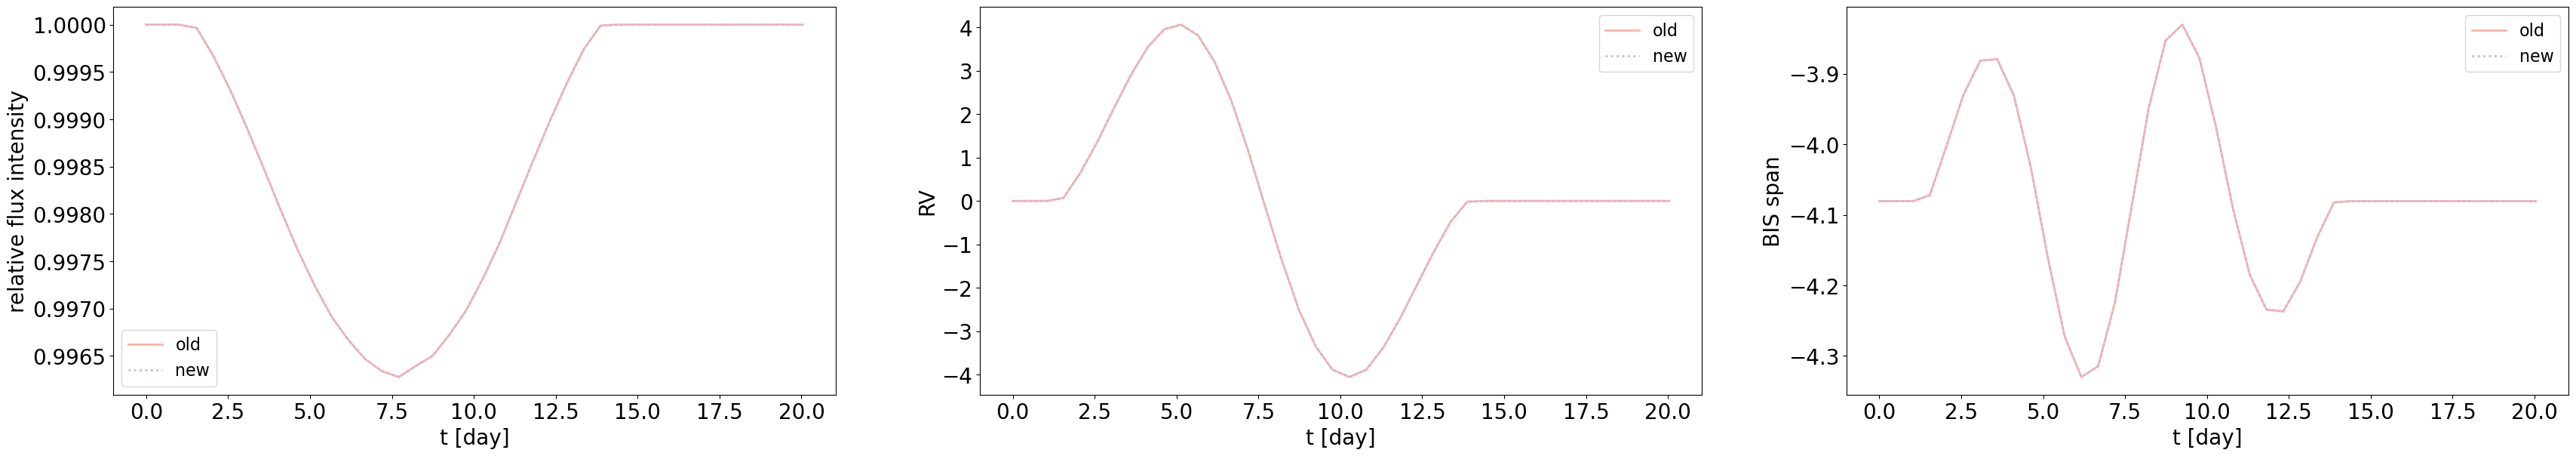

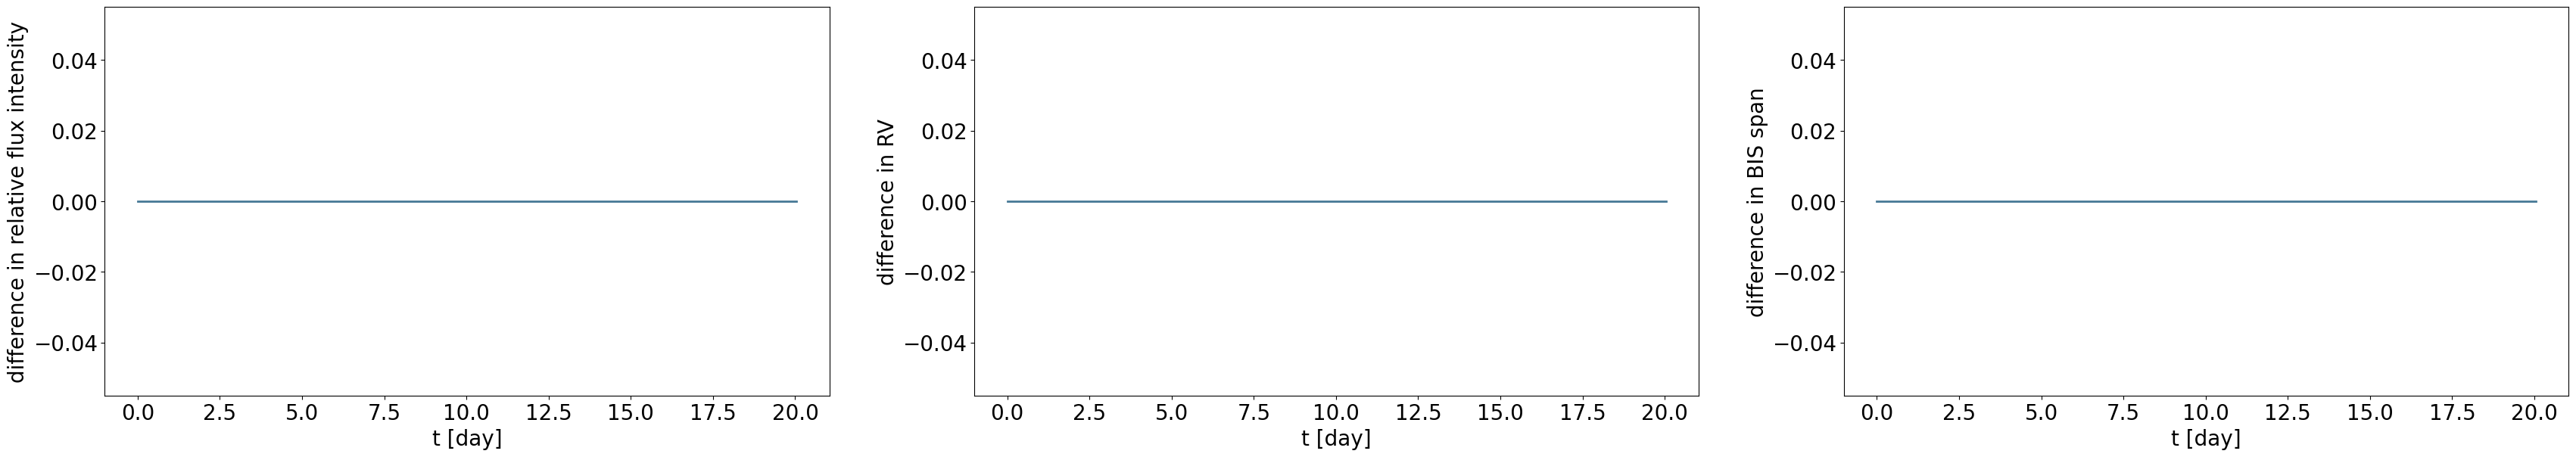

In [12]:
plt.rcParams['font.size'] = 20
plt.rcParams['lines.linewidth'] = 2
colors = ['#336b8b', '#f0b51f', '#83984d', '#fa8072', '#cab8d9']

# Spot case
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(60 / 1.5 + 2, 10 / 1.5))

ax[0].plot(t, lc_sp_old, color=colors[3], label='old', alpha=0.6)
ax[0].plot(t, lc_tot[0], ':', color=colors[4], label='new')

ax[1].plot(t, rv_sp_old, color=colors[3], label='old', alpha=0.6)
ax[1].plot(t, rv_tot[0], ':', color=colors[4], label='new')

ax[2].plot(t, bis_sp_old, color=colors[3], label='old', alpha=0.6)
ax[2].plot(t, bis_tot[0], ':', color=colors[4], label='new')

ax[0].legend(fontsize=16)
ax[0].set_xlabel('t [day]')
ax[0].set_ylabel('relative flux intensity')
ax[1].legend(fontsize=16)
ax[1].set_xlabel('t [day]')
ax[1].set_ylabel('RV')
ax[2].legend(fontsize=16)
ax[2].set_xlabel('t [day]')
ax[2].set_ylabel('BIS span')

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/spot_only.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(60 / 1.5 + 2, 10 / 1.5))

ax[0].plot(t, lc_sp_old-lc_tot[0], color=colors[0], alpha=0.9)
ax[1].plot(t, rv_sp_old-rv_tot[0], color=colors[0], alpha=0.9)
ax[2].plot(t, bis_sp_old-bis_tot[0], color=colors[0], alpha=0.9)

ax[0].set_xlabel('t [day]')
ax[0].set_ylabel('difference in relative flux intensity')
ax[1].set_xlabel('t [day]')
ax[1].set_ylabel('difference in RV')
ax[2].set_xlabel('t [day]')
ax[2].set_ylabel('difference in BIS span')

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/spot_only_diff.png', bbox_inches='tight')
plt.show()

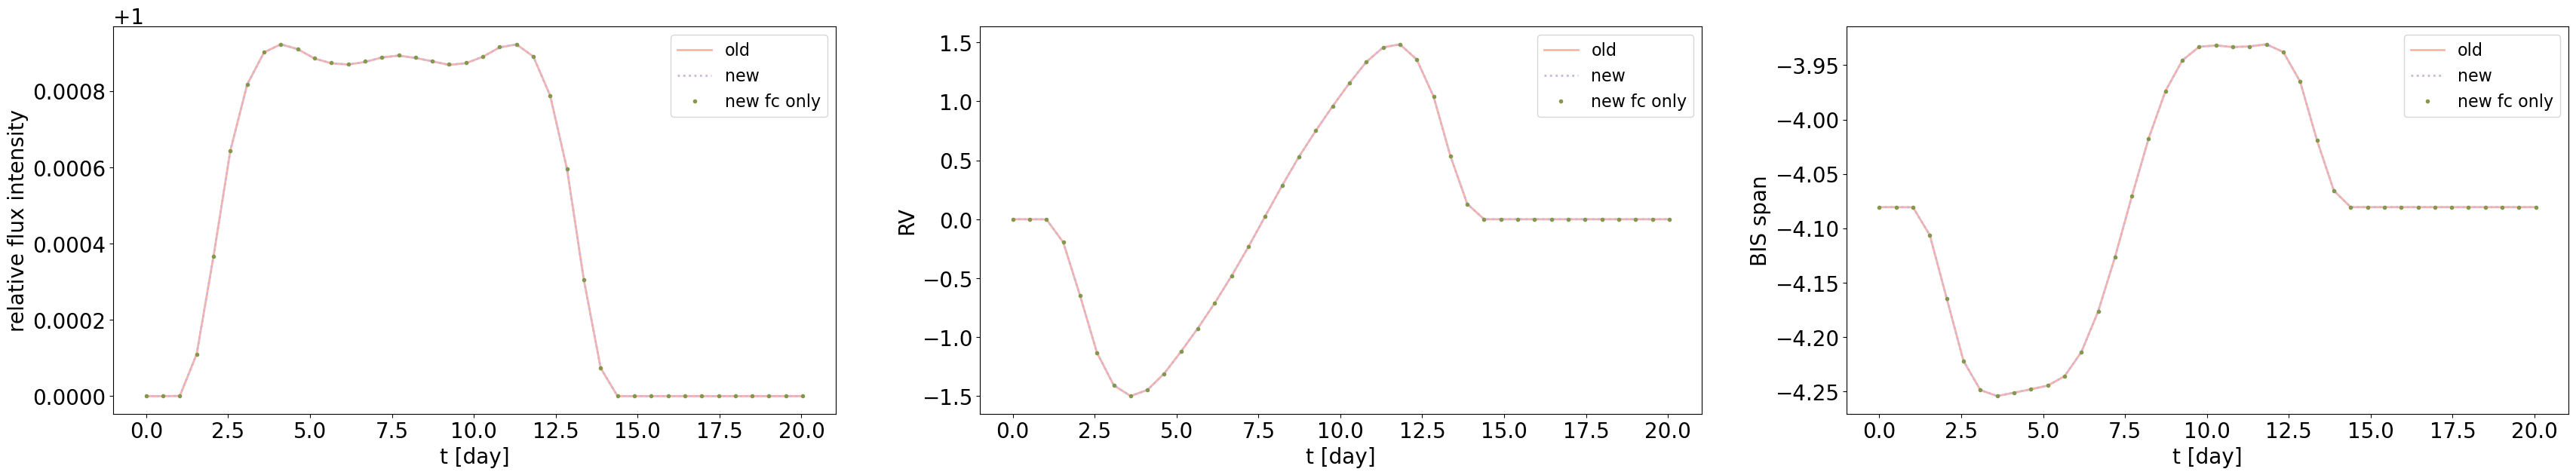

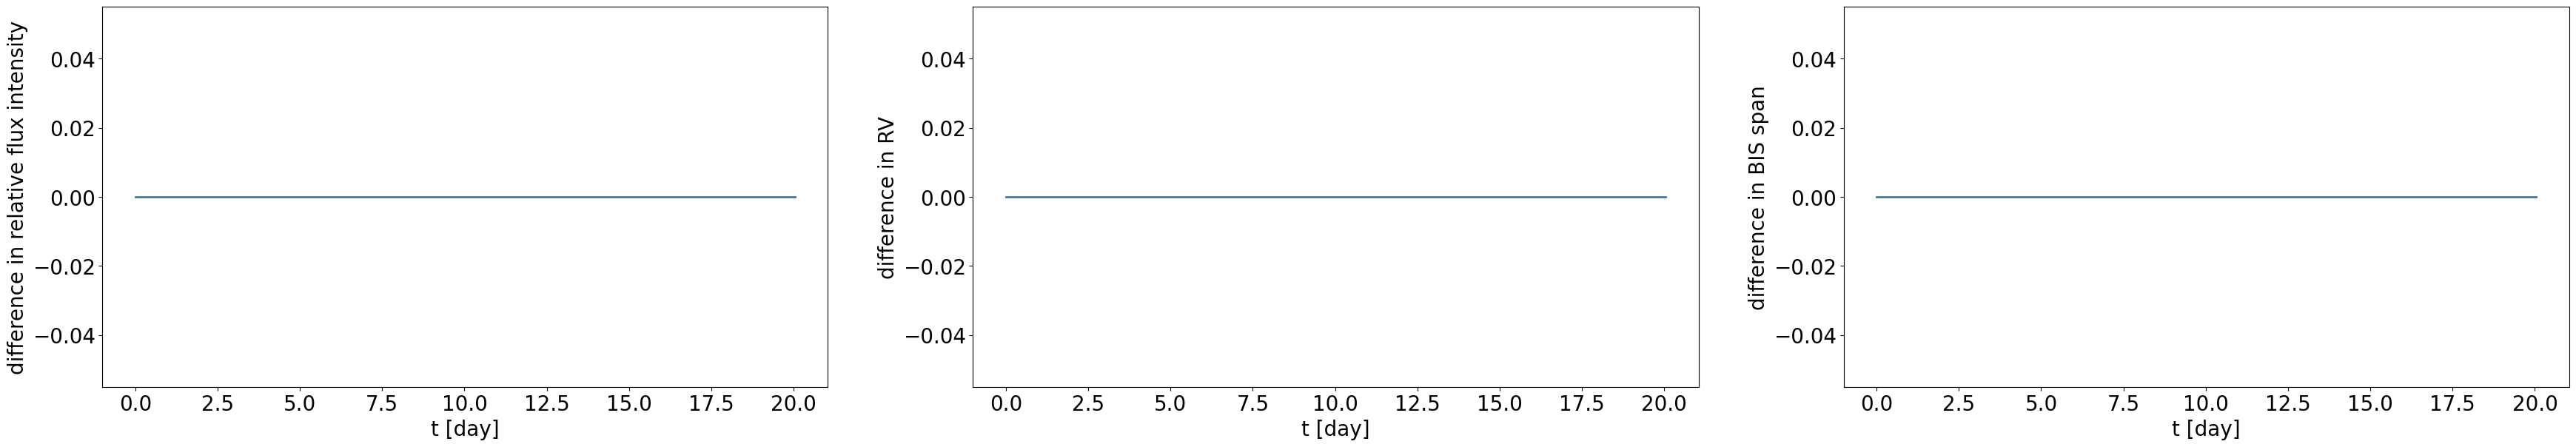

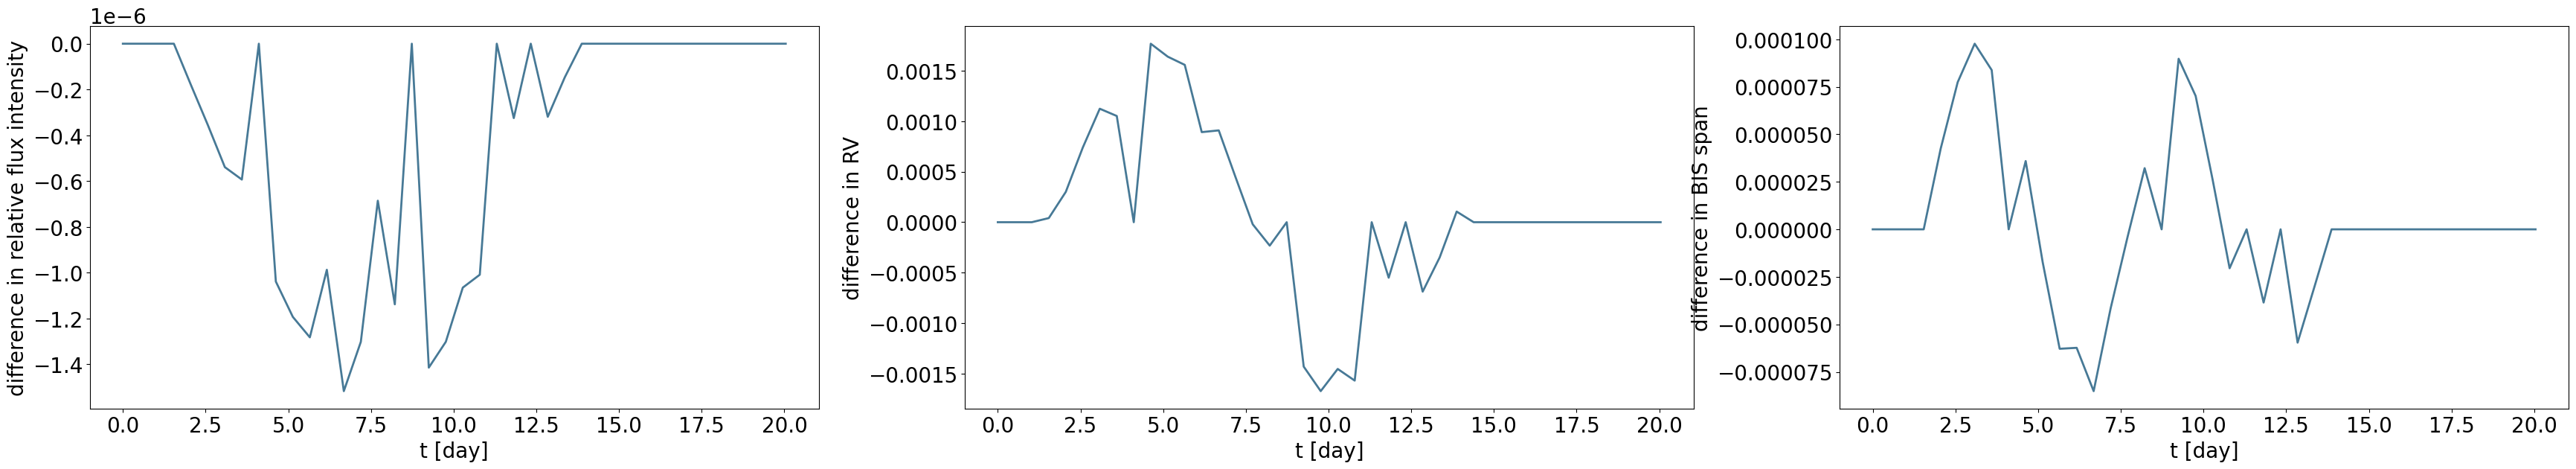

In [13]:
# Faculae case
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(60 / 1.5 + 2, 10 / 1.5))

ax[0].plot(t, lc_fc_old, color=colors[3], label='old', alpha=0.6)
ax[0].plot(t, lc_tot[2], ':', color=colors[4], label='new')
ax[0].plot(t, lc_tot[1], '.', color=colors[2], label='new fc only')


ax[1].plot(t, rv_fc_old, color=colors[3], label='old', alpha=0.6)
ax[1].plot(t, rv_tot[2], ':', color=colors[4], label='new')
ax[1].plot(t, rv_tot[1], '.', color=colors[2], label='new fc only')


ax[2].plot(t, bis_fc_old, color=colors[3], label='old', alpha=0.6)
ax[2].plot(t, bis_tot[2], ':', color=colors[4], label='new')
ax[2].plot(t, bis_tot[1], '.', color=colors[2], label='new fc only')



ax[0].legend(fontsize=16)
ax[0].set_xlabel('t [day]')
ax[0].set_ylabel('relative flux intensity')
ax[1].legend(fontsize=16)
ax[1].set_xlabel('t [day]')
ax[1].set_ylabel('RV')
ax[2].legend(fontsize=16)
ax[2].set_xlabel('t [day]')
ax[2].set_ylabel('BIS span')

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/faculae_only.png', bbox_inches='tight', dpi=300)
plt.show()

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(60 / 1.5 + 3, 10 / 1.5))

ax[0].plot(t, lc_fc_old-lc_tot[2], color=colors[0], alpha=0.9)
ax[1].plot(t, rv_fc_old-rv_tot[2], color=colors[0], alpha=0.9)
ax[2].plot(t, bis_fc_old-bis_tot[2], color=colors[0], alpha=0.9)

ax[0].set_xlabel('t [day]')
ax[0].set_ylabel('difference in relative flux intensity')
ax[1].set_xlabel('t [day]')
ax[1].set_ylabel('difference in RV')
ax[2].set_xlabel('t [day]')
ax[2].set_ylabel('difference in BIS span')

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/fac_only_diff.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(60 / 1.5 + 3, 10 / 1.5))

ax[0].plot(t, lc_fc_old-lc_tot[1], color=colors[0], alpha=0.9)
ax[1].plot(t, rv_fc_old-rv_tot[1], color=colors[0], alpha=0.9)
ax[2].plot(t, bis_fc_old-bis_tot[1], color=colors[0], alpha=0.9)

ax[0].set_xlabel('t [day]')
ax[0].set_ylabel('difference in relative flux intensity')
ax[1].set_xlabel('t [day]')
ax[1].set_ylabel('difference in RV')
ax[2].set_xlabel('t [day]')
ax[2].set_ylabel('difference in BIS span')

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/fac_only_diff_new_fc_only.png', bbox_inches='tight', dpi=300)
plt.show()

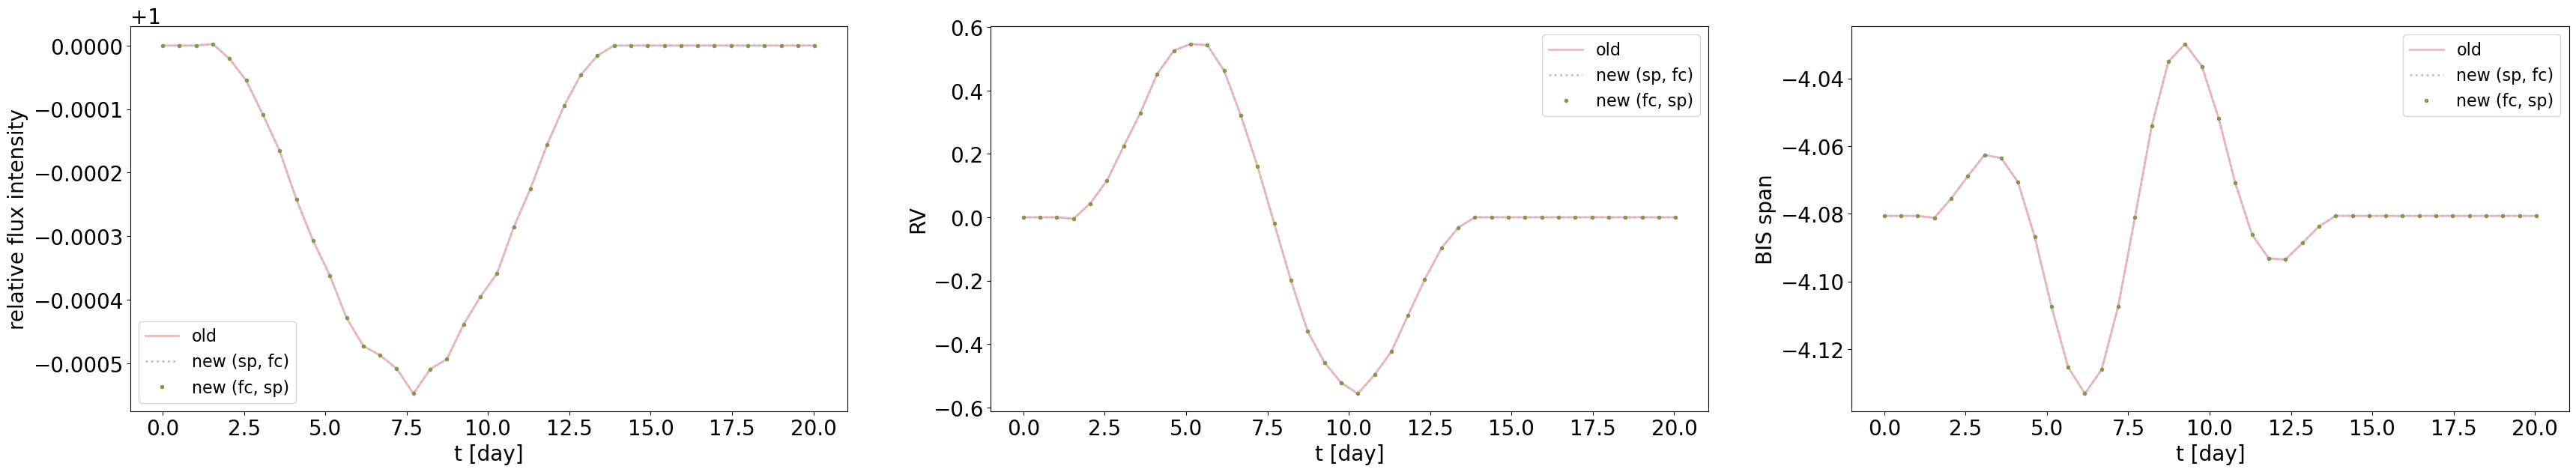

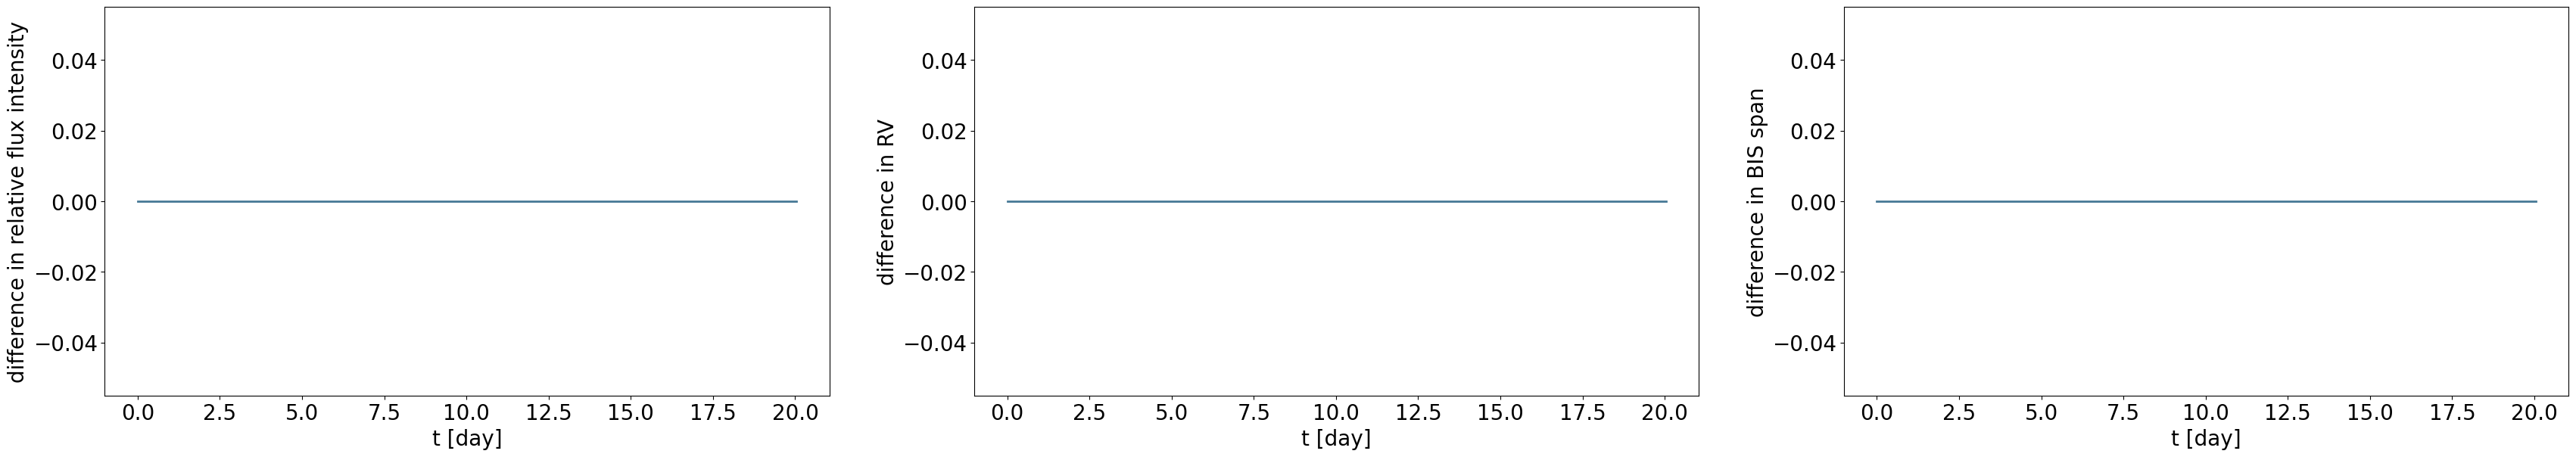

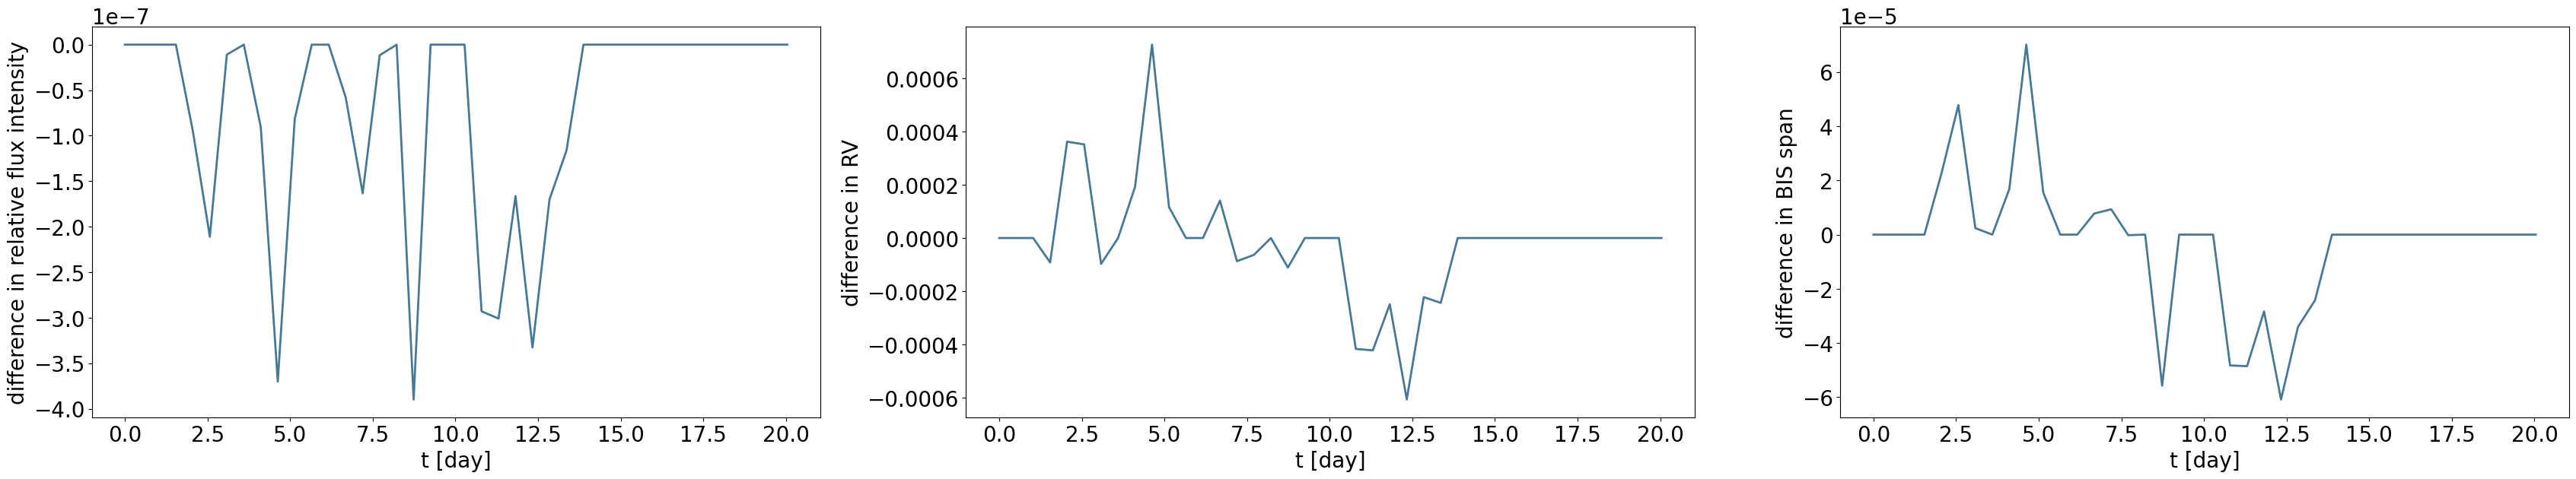

In [14]:
# Mixed case
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(60 / 1.5 + 2, 10 / 1.5))

ax[0].plot(t, lc_both_old, color=colors[3], label='old', alpha=0.6)
ax[0].plot(t, lc_tot[3], ':', color=colors[4], label='new (sp, fc)')
ax[0].plot(t, lc_tot[4], '.', color=colors[2], label='new (fc, sp)')


ax[1].plot(t, rv_both_old, color=colors[3], label='old', alpha=0.6)
ax[1].plot(t, rv_tot[3], ':', color=colors[4], label='new (sp, fc)')
ax[1].plot(t, rv_tot[4], '.', color=colors[2], label='new (fc, sp)')

ax[2].plot(t, bis_both_old, color=colors[3], label='old', alpha=0.6)
ax[2].plot(t, bis_tot[3], ':', color=colors[4], label='new (sp, fc)')
ax[2].plot(t, bis_tot[4], '.', color=colors[2], label='new (fc, sp)')

ax[0].legend(fontsize=16)
ax[0].set_xlabel('t [day]')
ax[0].set_ylabel('relative flux intensity')
ax[1].legend(fontsize=16)
ax[1].set_xlabel('t [day]')
ax[1].set_ylabel('RV')
ax[2].legend(fontsize=16)
ax[2].set_xlabel('t [day]')
ax[2].set_ylabel('BIS span')

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/mix.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(60 / 1.5 + 2, 10 / 1.5))

ax[0].plot(t, lc_both_old-lc_tot[3], color=colors[0], alpha=0.9)
ax[1].plot(t, rv_both_old-rv_tot[3], color=colors[0], alpha=0.9)
ax[2].plot(t, bis_both_old-bis_tot[3], color=colors[0], alpha=0.9)

ax[0].set_xlabel('t [day]')
ax[0].set_ylabel('difference in relative flux intensity')
ax[1].set_xlabel('t [day]')
ax[1].set_ylabel('difference in RV')
ax[2].set_xlabel('t [day]')
ax[2].set_ylabel('difference in BIS span')

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/mix_diff_(sp,fc).png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(60 / 1.5 + 2, 10 / 1.5))

ax[0].plot(t, lc_both_old-lc_tot[4], color=colors[0], alpha=0.9)
ax[1].plot(t, rv_both_old-rv_tot[4], color=colors[0], alpha=0.9)
ax[2].plot(t, bis_both_old-bis_tot[4], color=colors[0], alpha=0.9)

ax[0].set_xlabel('t [day]')
ax[0].set_ylabel('difference in relative flux intensity')
ax[1].set_xlabel('t [day]')
ax[1].set_ylabel('difference in RV')
ax[2].set_xlabel('t [day]')
ax[2].set_ylabel('difference in BIS span')

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/test_active_reg_type/mix_diff_(fc,sp).png', bbox_inches='tight')
plt.show()